### Verify performance: SR-derived formula vs baselines

Compares the published SR-derived formula against three baseline models (ESWF, WSA-ENLIL, 27-day persistence) plus a fourth "no information" baseline -- the average-prediction constant (AV) from Collin et al. (2025) -- on the Oct-Dec test months, ICME periods excluded, using [`src/evaluation/model_comparison.py`](../src/evaluation/model_comparison.py):
1. Entire-period metrics
2. Yearly metrics
3. Per-solar-cycle-phase metrics (MAE/RMSE/CC/DTW_mean) -- **this table is what goes into the paper**
4. A supplementary heatmap view of performance by OMNI speed range (not published; see [`figures/figure4_performance_by_speed_range.png`](../figures/figure4_performance_by_speed_range.png) for the published version)

In [1]:
import os, sys
sys.path.append(os.path.abspath("../src"))

import matplotlib.pyplot as plt

from evaluation.model_comparison import (
    build_comparison_df, evaluate_metrics, compute_binned_stats, SOLAR_CYCLE_PHASES,
)
from viz.performance import plot_binned_performance_heatmap

df, cr_df = build_comparison_df(data_dir="../data")
print(f"{len(df):,} rows, {df['datetime'].min()} to {df['datetime'].max()}")

Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


131,496 rows, 2010-01-01 00:00:00 to 2024-12-31 23:00:00


---

#### 1. Entire-period metrics

In [2]:
evaluate_metrics(df, group_by=None, include_dtw=True, dtw_window=48)

,MAE,RMSE,CC,N,DTW_mean,model
0,74.75,93.50,NaN,24789,74.80,av
1,60.02,78.37,0.549,24789,28.91,best_sr
2,82.26,108.94,0.379,24789,37.16,eswf2
3,70.86,96.16,0.459,24789,31.85,speed_p27
4,91.25,120.31,0.363,24789,54.83,wsa_enlil


---

#### 2. Yearly metrics

In [3]:
evaluate_metrics(df, group_by="year", include_dtw=True, dtw_window=48)

,MAE,RMSE,CC,N,DTW_mean,model,year
0,76.02,93.15,NaN,1877,76.02,av,2010
1,67.08,85.76,0.408,1877,28.61,best_sr,2010
2,82.38,113.64,0.291,1877,33.47,eswf2,2010
3,81.75,105.63,0.321,1877,35.57,speed_p27,2010
4,80.13,112.61,0.354,1877,47.31,wsa_enlil,2010
...,...,...,...,...,...,...,...
70,52.87,71.60,NaN,1429,52.71,av,2024
71,61.20,78.14,-0.054,1429,32.54,best_sr,2024
72,74.76,95.75,0.039,1429,39.93,eswf2,2024
73,70.87,94.75,-0.092,1429,36.70,speed_p27,2024


---

#### 3. Per-solar-cycle-phase metrics (paper table)

Includes DTW_mean, the mean Dynamic Time Warping distance (Samara et al. 2022; Edward-Inatimi et al. 2026; also now shown for the yearly table in Section 2) alongside MAE/RMSE/CC -- DTW_mean captures whether the *shape*/timing of predicted enhancements matches observations, not just pointwise error. Computed directly on the physical-unit (km/s) speed series (no z-scoring), using dtaidistance's `inner_dist="euclidean"` mode: D(i,j) = |s_i - q_j| + min(D(i-1,j-1), D(i-1,j), D(i,j-1)). This matches both the equation in Samara et al. (2022) and the actual implementation in their own cited reference code (github.com/SamaraEvangelia/DTW_ForSolarWindEvaluation) -- dtaidistance's *default* inner distance is squared Euclidean with a single sqrt applied at the end instead, which gives a materially different number, not this one. Uses a +-2-day (48 hr) Sakoe-Chiba window, adopted directly from Samara et al. (2022)'s own EUHFORIA window rather than a value derived from our own data: an attempt to measure a comparable window empirically via `notebooks/06_hss_event_detection.ipynb`'s `peak_bias_stats()` (nearest-neighbor peak matching within a fixed net) turned out to be unreliable -- widening that net from 24h to 168h never let `dt_std_hr`/`dt_mae_hr` converge to a stable value (for the SR-derived formula, `dt_std_hr` goes 12.8h at a 24h net -> 29.9h at 72h -> 59.8h at 168h, still climbing), and even the +-72h net already leaves ~52% of OMNI peaks with no matched model peak at all (excluded from the statistic entirely, not just from the tail). Since greedy nearest-peak matching doesn't yield a trustworthy 'typical' timing offset for this dataset, we use Samara et al.'s own published +-2-day figure directly instead of a self-derived one. Two further corrections vs. a naive implementation: (1) DTW is computed once per calendar-contiguous block (split wherever the 1-hour cadence breaks in a way that isn't bridgeable -- see below) and summed across blocks; (2) the reported value is that total cost divided by the total warping-path length (not the raw point count N), which correctly dilutes singularities -- points matched more than once -- across the extra matched pairs they actually produced, keeping the result on the same km/s scale as MAE/RMSE and comparable both *within* a row and *across* rows (e.g. different phases).

Block-splitting itself is gap-aware, not just year-aware: AIA excludes *every* 21:00 UT frame daily (dark-frame calibration; see the paper's Data section), which -- via `best_sr`'s 96h/4-day CH lag, a multiple of 24h -- becomes a structural, guaranteed single missing hour (20:00->22:00) at the *same* hour-of-day every day in the merged dataset. Splitting a new DTW block at every one of these would fragment nearly every contiguous observing run into ~daily chunks for no physical reason (confirmed empirically: 1079 of 1380 total gaps in the entire-period, ICME-excluded dataset are exactly this single missing hour, 1051 of those ending at hour 22). `_build_dtw_blocks()` instead bridges any gap of at most `dtw_gap_tolerance_hours` (default 1) consecutive missing hours via linear interpolation -- for a single missing hour this is just the (a+b)/2 average of its two real neighbors -- rather than starting a new block, cutting the entire-period block count from 1381 to 302. ICME periods are never bridged this way, regardless of duration: a gap is only eligible for interpolation if it does *not* overlap any ICME interval (checked directly against `fetch_icme_events()`'s interval list), since ICME-driven disturbances are physically distinct from the ambient CH-driven wind this comparison targets, and smoothing a straight line across one would fabricate values, not fill in noise.

`av` is the average-prediction baseline (Collin et al. 2025): a constant equal to the mean OMNI speed over the Jan-Sep training months, scoped to match each row (the single 2010-2024 training mean for the entire-period row, that phase's own training mean for each phase row -- see `evaluate_metrics()`'s docstring). Included to show that a low RMSE alone doesn't imply real predictive skill: `av`'s CC is undefined by construction (zero-variance prediction), while `best_sr`'s CC is not.

In [4]:
phase_metrics_df = evaluate_metrics(
    df, group_by="phase", groups=SOLAR_CYCLE_PHASES, include_dtw=True, dtw_window=48,
)
phase_metrics_df

,MAE,RMSE,CC,N,DTW_mean,model,phase
0,82.49,100.91,NaN,7340,82.56,av,Declining
1,54.66,70.48,0.716,7340,21.71,best_sr,Declining
2,76.64,102.14,0.523,7340,28.93,eswf2,Declining
3,66.60,88.63,0.624,7340,24.81,speed_p27,Declining
4,86.10,114.17,0.470,7340,40.92,wsa_enlil,Declining
5,61.84,81.94,NaN,4821,61.85,av,Maximum
6,59.53,77.70,0.344,4821,32.60,best_sr,Maximum
7,79.23,101.33,0.177,4821,41.41,eswf2,Maximum
8,63.43,87.78,0.324,4821,31.37,speed_p27,Maximum
9,91.34,112.76,0.303,4821,62.64,wsa_enlil,Maximum


---

#### 4. Performance by OMNI speed range (supplementary heatmap view)

Same binned statistics as Figure 3, with an added heatmap row for a quicker at-a-glance read. Exploratory only -- not saved as a separate file, shown inline here.

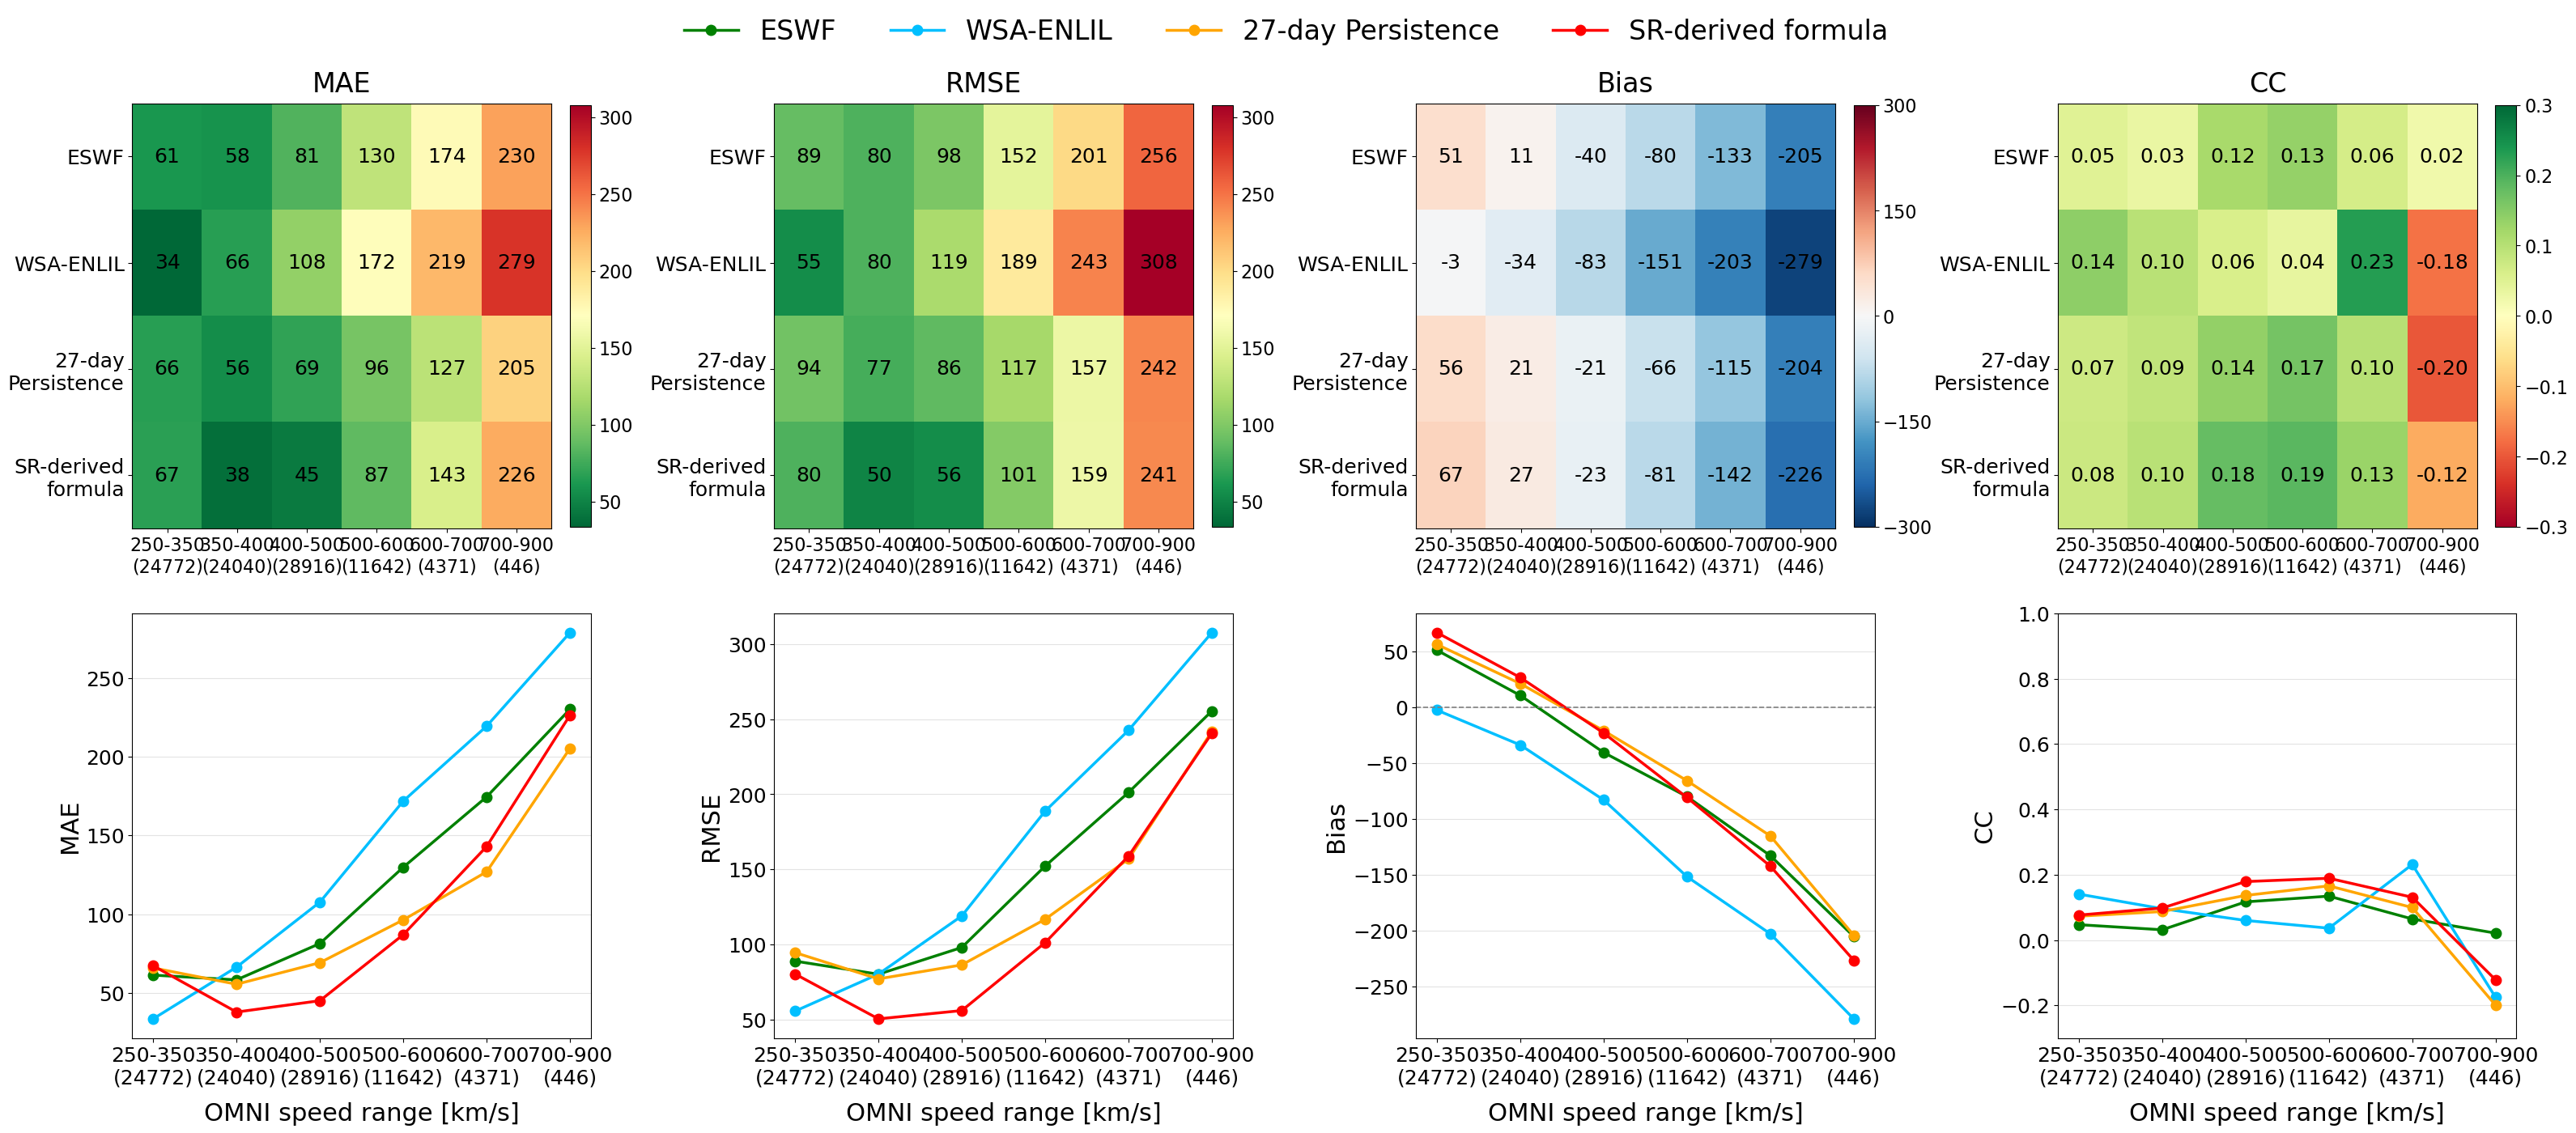

In [5]:
model_specs = [
    ("eswf2", "ESWF"),
    ("wsa_enlil", "WSA-ENLIL"),
    ("speed_p27", "Persistence (27 days)"),
    ("best_sr", "SR-derived formula"),
]
color_map = {"ESWF": "green", "WSA-ENLIL": "deepskyblue",
            "Persistence (27 days)": "orange", "SR-derived formula": "red"}
speed_bins = [250, 350, 400, 500, 600, 700, 900]

stats_dict, bin_labels = compute_binned_stats(df, model_specs, speed_bins, min_samples=10)

plot_binned_performance_heatmap(stats_dict, bin_labels, color_map, metrics=("MAE", "RMSE", "Bias", "CC"))
plt.show()

---

#### 5. Latitude-band sensitivity: is A60xP30 actually the best choice?

The published formula uses $A_{CH60}$ and $P_{CH30}$ specifically. This rebuilds the formula for all 9 combinations of A/P latitude band (30/60/90 deg each) and checks where A60xP30 ranks by RMSE, per phase.

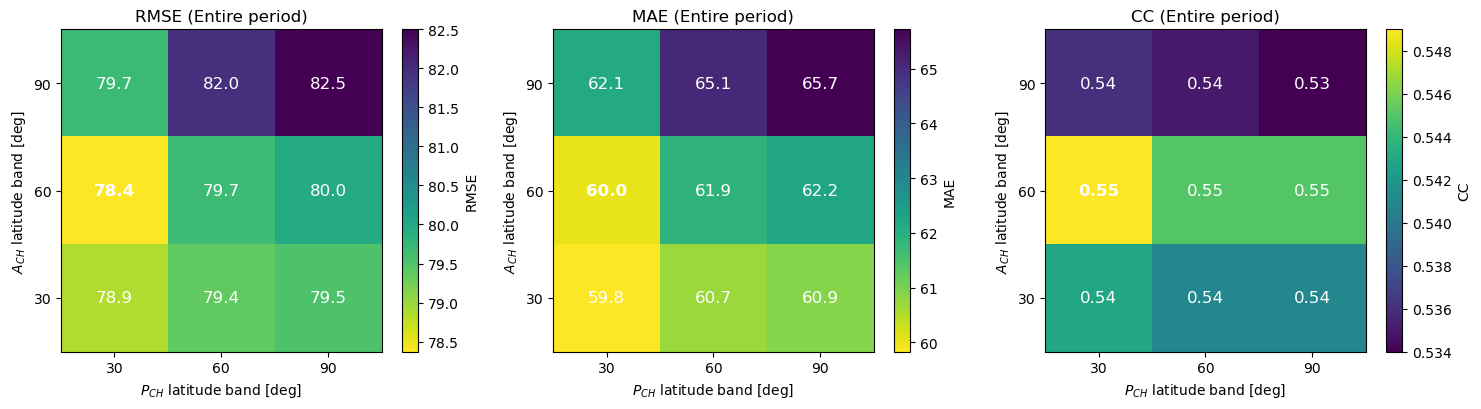

In [6]:
from evaluation.model_comparison import evaluate_latitude_combinations
from viz.performance import plot_latitude_combo_heatmap

combo_df = evaluate_latitude_combinations(df)

plot_latitude_combo_heatmap(combo_df, phase="Entire")
plt.show()

Best combination per phase, and where the published A60xP30 formula ranks out of 9:

In [7]:
best_per_phase = (
    combo_df.loc[combo_df.groupby("phase")["RMSE"].idxmin(), ["phase", "model", "MAE", "RMSE", "CC"]]
    .reset_index(drop=True)
)
print("Best combo per phase:")
print(best_per_phase.to_string(index=False))

print("\nA60xP30 (published) rank by RMSE:")
for phase in combo_df["phase"].unique():
    ranked = combo_df[combo_df["phase"] == phase].sort_values("RMSE").reset_index(drop=True)
    rank = ranked.index[ranked["model"] == "sr_A60_P30"][0] + 1
    rmse = ranked.loc[ranked["model"] == "sr_A60_P30", "RMSE"].values[0]
    print(f"  {phase:10s}: rank {rank}/9  (RMSE={rmse})")

Best combo per phase:
    phase      model   MAE  RMSE    CC
Declining sr_A60_P30 54.66 70.48 0.716
   Entire sr_A60_P30 60.02 78.37 0.549
  Maximum sr_A90_P30 59.35 77.41 0.353
  Minimum sr_A30_P90 47.32 60.24 0.638
   Rising sr_A30_P30 68.57 89.90 0.373

A60xP30 (published) rank by RMSE:
  Declining : rank 1/9  (RMSE=70.48)
  Entire    : rank 1/9  (RMSE=78.37)
  Maximum   : rank 2/9  (RMSE=77.7)
  Minimum   : rank 6/9  (RMSE=61.45)
  Rising    : rank 2/9  (RMSE=90.28)


---

#### 6. Taylor diagram (entire test period)

Standard deviation vs. correlation coefficient against OMNI, for each model over the whole entire-period test set (same Oct-Dec / ICME-excluded filtering as Section 1). `av` is excluded since it is a constant (zero standard deviation, undefined correlation) and cannot be placed on a Taylor diagram.

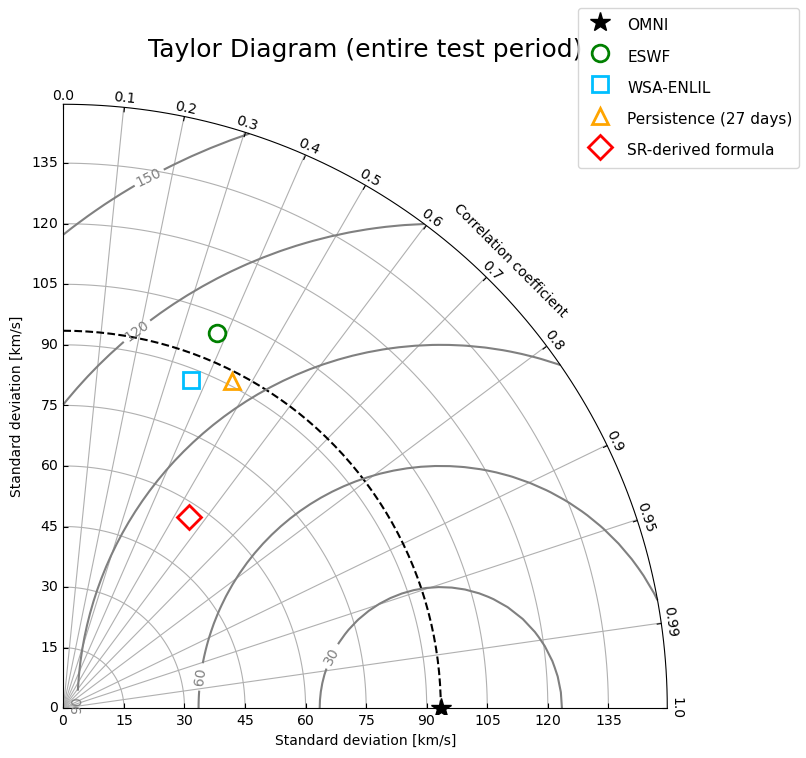

In [8]:
from viz.taylor import plot_taylor_diagram

taylor_specs = [
    ("eswf2", "ESWF", "green", "o"),
    ("wsa_enlil", "WSA-ENLIL", "deepskyblue", "s"),
    ("speed_p27", "Persistence (27 days)", "orange", "^"),
    ("best_sr", "SR-derived formula", "red", "D"),
]

plot_taylor_diagram(df, taylor_specs)
plt.show()